# Figure 2: Global distribution and ecological architecture of fldAIBC carriers

Run the notebook from top to bottom. It works when the current working directory is either the repository root or `notebooks/`.

The four plotting cells retain the original source order and correspond to panels **a**, **b**, **c** and **d**. Previous panel labels embedded in the source have been reconciled with that order.

| Panel | Plot | Packaged inputs |
| --- | --- | --- |
| a | Country prevalence map and sample-size bubbles | Country summary and Natural Earth boundaries |
| b | Carrier prevalence versus abundance | Carrier prevalence/abundance summary |
| c | Presence-conditional abundance of four carrier groups | Carrier count matrix, sample read totals and carrier summary |
| d | Within-sample composition, richness and dominance | Sample-state and richness summaries and carrier count matrix |

Inputs in `../data/figure2/` are copied plotting inputs. The code retains the original data transformations and plotting settings. No upstream screening or metagenomic mapping pipeline is required. Figures are written to `../outputs/figure2/` in SVG, PDF, PNG and TIFF formats; derived source-data tables are written to its `source_data/` subdirectory.

The map uses the packaged Natural Earth 1:110m country boundary asset, which is in the public domain. Map download and remote filesystem access are unnecessary.


In [1]:
%matplotlib inline

from pathlib import Path

# Locate the repository from either the repository root or the notebooks directory.
current_dir = Path.cwd()
REPO_ROOT = next(
    (candidate for candidate in (current_dir, current_dir.parent)
     if (candidate / 'data' / 'figure2').is_dir() and (candidate / 'notebooks').is_dir()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError('Run this notebook from the repository root or notebooks directory.')

DATA_DIR = REPO_ROOT / 'data' / 'figure2'
OUTPUT_DIR = REPO_ROOT / 'outputs' / 'figure2'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Panel a: Global carrier prevalence

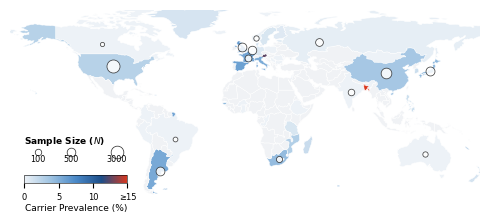

In [2]:
# ==============================================================================
# Panel 2a: Global World Map of Carrier Prevalence (Choropleth + Sample Bubbles)
# ==============================================================================
import json
import math
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.collections import PatchCollection
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import Polygon
import numpy as np
import pandas as pd

src_file = DATA_DIR / 'Figure2a_country_carrier_prevalence.tsv'
geo_file = DATA_DIR / 'ne_110m_admin_0_countries.geojson'

out_dir = OUTPUT_DIR
out_dir.mkdir(parents=True, exist_ok=True)

country_df = pd.read_csv(src_file, sep='\t')
with open(geo_file, 'r', encoding='utf-8') as f:
    world = json.load(f)

# Figure dimensions in millimetres.
WIDTH_MM = 170
HEIGHT_MM = 62
# --------------------------------------------

fig, ax = plt.subplots(figsize=(WIDTH_MM / 25.4, HEIGHT_MM / 25.4))
ax.set_facecolor('white')
ax.set_aspect('equal')

COUNTRY_ALIASES = {
    'United States': 'United States of America',
    'Congo': 'Republic of the Congo',
    'Serbia': 'Republic of Serbia',
    'Tanzania': 'United Republic of Tanzania',
    'Czech Republic': 'Czechia'
}
CURATED_CENTROIDS = {
    'United States': (-98.58, 39.83),
    'United States of America': (-98.58, 39.83),
    'France': (2.21, 46.23),
    'United Kingdom': (-2.2, 54.5),
    'Netherlands': (5.29, 52.13),
    'Norway': (8.47, 60.47),
    'Russia': (55.0, 58.0),
    'China': (105.0, 35.0),
    'Japan': (138.0, 36.5),
    'Australia': (133.77, -25.27),
    'Canada': (-106.35, 56.13),
    'Brazil': (-51.92, -14.23),
    'Argentina': (-63.61, -38.41),
    'India': (78.96, 20.59),
    'South Africa': (25.0, -29.0)
}

lookup = {COUNTRY_ALIASES.get(r.country, r.country): r for r in country_df.itertuples()}
for r in country_df.itertuples():
    lookup[r.country] = r

cmap = LinearSegmentedColormap.from_list('carrier_map', ['#EDF2F7', '#A0C4E2', '#4A89C8', '#1D4E89', '#D9381E'], N=256)
vmax = 15.0
norm = Normalize(vmin=0.0, vmax=vmax)
patches, facecolors = [], []

def get_polygons(geom):
    if not geom:
        return []
    t = geom.get('type')
    c = geom.get('coordinates', [])
    if t == 'Polygon' and len(c) > 0:
        return [np.asarray(c[0], dtype=float)]
    if t == 'MultiPolygon' and len(c) > 0:
        return [np.asarray(p[0], dtype=float) for p in c]
    return []

for feat in world.get('features', []):
    props = feat.get('properties', {})
    names = [props.get(k) for k in ['ADMIN', 'NAME', 'NAME_EN', 'SOVEREIGNT', 'GEOUNIT'] if props.get(k)]
    m = None
    for n in names:
        if n in lookup:
            m = lookup[n]
            break
    col = cmap(norm(min(m.prevalence_percent, vmax))) if m is not None else '#F0F2F5'
    for poly in get_polygons(feat.get('geometry', {})):
        patches.append(Polygon(poly, closed=True))
        facecolors.append(col)

coll = PatchCollection(patches, facecolor=facecolors, edgecolor='#FFFFFF', linewidth=0.35, zorder=1)
ax.add_collection(coll)

max_n = float(country_df['n_samples'].max())
for r in country_df.itertuples():
    cn = r.country
    xy = CURATED_CENTROIDS.get(cn) or CURATED_CENTROIDS.get(COUNTRY_ALIASES.get(cn))
    if xy is not None:
        s = 8.0 + 80.0 * math.sqrt(r.n_samples / max_n)
        ax.scatter(xy[0], xy[1], s=s, facecolor='white', edgecolor='#222222', linewidth=0.55, alpha=0.85, zorder=3)

ax.set_xlim(-175, 175)
ax.set_ylim(-58, 82)
ax.set_xticks([])
ax.set_yticks([])
for sp in ax.spines.values():
    sp.set_visible(False)

# Inset Colorbar
cax = ax.inset_axes([0.03, 0.08, 0.22, 0.04])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cb = plt.colorbar(sm, cax=cax, orientation='horizontal')
cb.set_label('Carrier Prevalence (%)', fontsize=6.5, labelpad=2)
cb.set_ticks([0, 5, 10, 15])
cb.set_ticklabels(['0', '5', '10', '≥15'], fontsize=6)
cb.outline.set_linewidth(0.4)

# Inset Legend
leg_ax = ax.inset_axes([0.03, 0.18, 0.24, 0.12])
leg_ax.set_axis_off()
leg_ax.text(0.0, 0.85, 'Sample Size ($N$)', fontsize=6.5, fontweight='bold')
for n_val, xp in zip([100, 500, 3000], [0.12, 0.42, 0.82]):
    leg_ax.scatter(xp, 0.35, s=8.0 + 80.0 * math.sqrt(n_val / max_n), facecolor='white', edgecolor='#222222', linewidth=0.5)
    leg_ax.text(xp, -0.15, f'{n_val}', fontsize=5.8, ha='center')
leg_ax.set_xlim(0, 1)
leg_ax.set_ylim(-0.3, 1)


for ext, kw in [('.svg', {}), ('.pdf', {}), ('.png', {'dpi': 300}), ('.tiff', {'dpi': 600, 'pil_kwargs': {'compression': 'raw'}})]:
    fig.savefig(out_dir / f'Fig2a_world_carrier_map{ext}', bbox_inches='tight', **kw)
plt.show()


## Panel b: Carrier prevalence and abundance

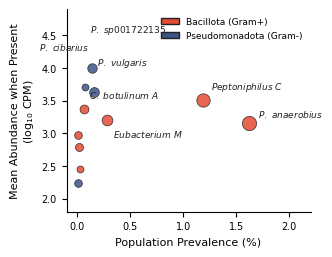

In [3]:
# ==============================================================================
# Panel 2b: Prevalence-Abundance 2D Ecological Landscape
# ==============================================================================
import math
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
import numpy as np
import pandas as pd
import seaborn as sns

prof_df = pd.read_csv(DATA_DIR / 'Figure2b_carrier_prevalence_abundance.tsv', sep='\t')
out_dir = OUTPUT_DIR
out_dir.mkdir(parents=True, exist_ok=True)

WIDTH_MM = 86
HEIGHT_MM = 68

fig, ax = plt.subplots(figsize=(WIDTH_MM / 25.4, HEIGHT_MM / 25.4))
det = prof_df[prof_df['n_positive_samples'] > 0].copy()

for _, row in det.iterrows():
    col = '#E64B35' if row['phylum'] == 'Bacillota' else '#3C5488'
    s = 25.0 + 80.0 * math.sqrt(row['n_dominant'] / 178.0)
    ax.scatter(row['prev_pct'], row['log10_mean_cpm_pos'], s=s, color=col, alpha=0.85, edgecolors='#222222', linewidth=0.55, zorder=3)

annotations = [
    ('UHGG_C07', r'$\mathit{P.\ anaerobius}$', 1.62, 3.35, 0.08, -0.05, 'left'),
    ('UHGG_C04', r'$\mathit{Peptoniphilus\ C}$', 1.18, 3.59, 0.08, 0.12, 'left'),
    ('UHGG_C11', r'$\mathit{Eubacterium\ M}$', 0.29, 3.22, 0.05, -0.22, 'left'),
    ('UHGG_C19', r'$\mathit{P.\ cibarius}$', 0.15, 4.18, -0.04, 0.15, 'right'),
    ('UHGG_C28', r'$\mathit{P.\ vulgaris}$', 0.14, 4.23, 0.05, -0.15, 'left'),
    ('UHGG_C26', r'$\mathit{P.\ sp001722135}$', 0.07, 4.50, 0.05, 0.08, 'left'),
    ('UHGG_C14', r'$\mathit{C.\ botulinum\ A}$', 0.065, 3.41, 0.05, 0.18, 'left'),
]
for cid, text, x, y, dx, dy, align in annotations:
    ax.text(x + dx, y + dy, text, fontsize=6.5, ha=align, va='center', color='#222222', zorder=5)

ax.set_xlabel('Population Prevalence (%)', fontsize=8)
ax.set_ylabel('Mean Abundance when Present\n($\log_{10}$ CPM)', fontsize=8)
ax.set_xlim(-0.1, 2.2)
ax.set_ylim(1.8, 4.9)

# Show only the major x-axis ticks.
ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.tick_params(axis='both', labelsize=7)

legend_elements = [
    Patch(facecolor='#E64B35', edgecolor='#222222', label='Bacillota (Gram+)'),
    Patch(facecolor='#3C5488', edgecolor='#222222', label='Pseudomonadota (Gram-)'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=6.5, frameon=False)
sns.despine(ax=ax)

plt.tight_layout()
for ext, kw in [('.svg', {}), ('.pdf', {}), ('.png', {'dpi': 300}), ('.tiff', {'dpi': 600, 'pil_kwargs': {'compression': 'raw'}})]:
    fig.savefig(out_dir / f'Fig2b_carrier_prevalence_abundance{ext}', bbox_inches='tight', **kw)
plt.show()


## Panel c: Carrier-group abundance

meta NOT subset; don't know how to subset; dropped


Carrier matrix: 14 genomes x 12238 samples
Carrier-positive sample union: 379
Sample-group observations: 419
              carrier_group  n_member_genomes  n_detected_member_genomes  n_positive_samples  median_log10_cpm_plus1  q25_log10_cpm_plus1  q75_log10_cpm_plus1  min_log10_cpm_plus1  max_log10_cpm_plus1
   Complete (P. anaerobius)                 1                          1                 198                2.439113             1.909938             3.171009             0.895356             4.393495
Complete (Pept. C & allies)                 7                          5                 155                3.260313             2.407176             3.624983             1.352145             4.450854
              Dual Cassette                 5                          4                  31                2.551555             2.194729             2.835669             1.763416             5.434893
                 Incomplete                 1                          1               

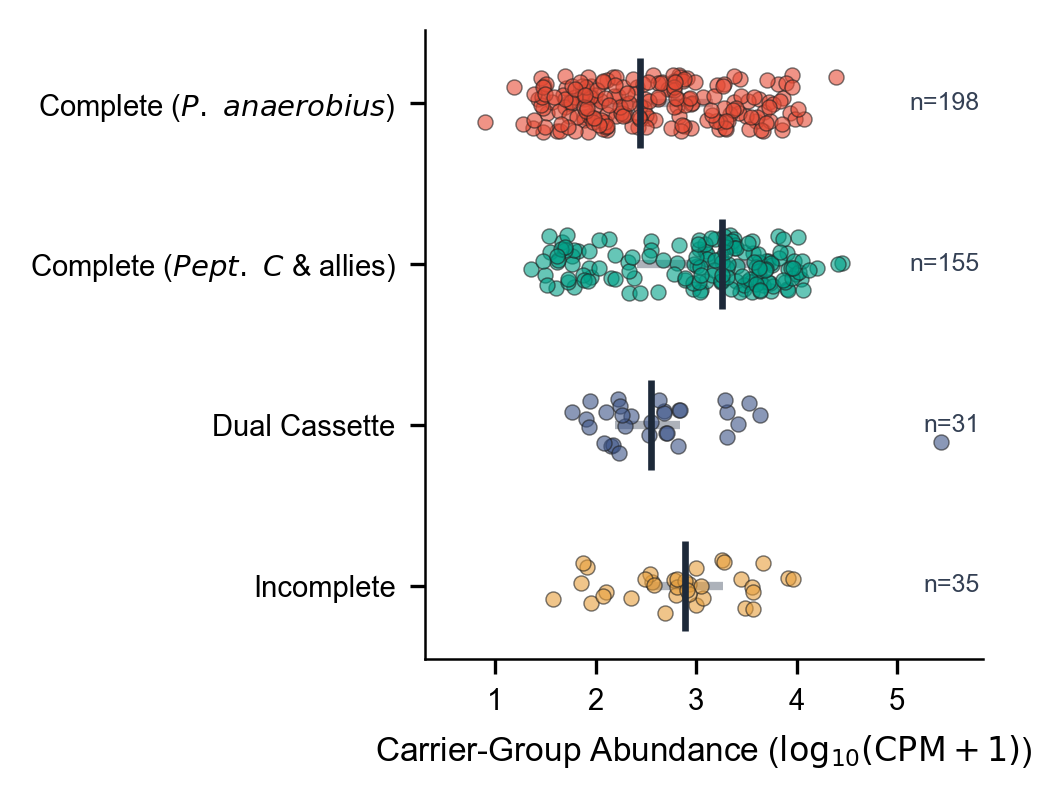

In [4]:
# ==============================================================================
# Panel 2c: Carrier-group-specific abundance without sample assignment
# ==============================================================================
from pathlib import Path
import hashlib
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np
import pandas as pd
import seaborn as sns

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
    'axes.linewidth': 0.6,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

counts = pd.read_csv(
    DATA_DIR / 'carrier_by_sample_counts.tsv.gz',
    sep='\t',
    index_col=0,
)
samples = pd.read_csv(
    DATA_DIR / 'sample_fld_landscape_metrics.tsv',
    sep='\t',
)
profile = pd.read_csv(
    DATA_DIR / 'Figure2b_carrier_prevalence_abundance.tsv',
    sep='\t',
)
if 'sample_id' not in samples.columns:
    samples['sample_id'] = samples['Unnamed: 0']

# Four mutually exclusive carrier/island-architecture groups.
GROUP_MEMBERS = {
    'Complete (P. anaerobius)': [
        'GUT_GENOME003569',
    ],
    'Complete (Pept. C & allies)': [
        'GUT_GENOME000611',
        'GUT_GENOME095982',
        'GUT_GENOME096493',
        'GUT_GENOME097942',
        'GUT_GENOME098616',
        'GUT_GENOME141698',
        'GUT_GENOME207305',
    ],
    'Dual Cassette': [
        'GUT_GENOME098791',
        'GUT_GENOME145984',
        'GUT_GENOME142612',
        'GUT_GENOME140352',
        'GUT_GENOME231559',
    ],
    'Incomplete': [
        'GUT_GENOME031326',
    ],
}
GROUP_ORDER = list(GROUP_MEMBERS)
GROUP_COLORS = {
    'Complete (P. anaerobius)': '#E64B35',
    'Complete (Pept. C & allies)': '#00A087',
    'Dual Cassette': '#3C5488',
    'Incomplete': '#E79F3C',
}
GROUP_LABELS = {
    'Complete (P. anaerobius)': r'Complete ($\mathit{P.\ anaerobius}$)',
    'Complete (Pept. C & allies)': r'Complete ($\mathit{Pept.\ C}$ & allies)',
    'Dual Cassette': 'Dual Cassette',
    'Incomplete': 'Incomplete',
}

mapped_genomes = [genome for members in GROUP_MEMBERS.values() for genome in members]
if len(mapped_genomes) != len(set(mapped_genomes)):
    raise ValueError('A carrier genome is assigned to more than one group.')
if set(mapped_genomes) != set(counts.index):
    missing = sorted(set(counts.index) - set(mapped_genomes))
    extra = sorted(set(mapped_genomes) - set(counts.index))
    raise ValueError(f'Carrier-group mapping mismatch; missing={missing}, extra={extra}.')
if set(profile['genome_id']) != set(counts.index):
    raise ValueError('Carrier profile IDs do not match the 14-carrier count matrix.')

total_reads = (
    samples.set_index('sample_id')['total_reads']
    .reindex(counts.columns)
    .astype(float)
)
if total_reads.isna().any() or (total_reads <= 0).any():
    raise ValueError('CPM denominator is missing or non-positive.')

# Sum reads within each carrier group for every sample, then normalize.
group_raw_reads = pd.DataFrame(index=GROUP_ORDER, columns=counts.columns, dtype=float)
group_n_carriers = pd.DataFrame(index=GROUP_ORDER, columns=counts.columns, dtype=int)
for group, members in GROUP_MEMBERS.items():
    group_raw_reads.loc[group] = counts.loc[members].sum(axis=0)
    group_n_carriers.loc[group] = counts.loc[members].gt(0).sum(axis=0)

# Conservation check: four group totals must reconstruct the 14-carrier total.
total_carrier_reads = counts.sum(axis=0).astype(float)
if not np.array_equal(
    group_raw_reads.sum(axis=0).to_numpy(float),
    total_carrier_reads.to_numpy(float),
):
    raise ValueError('Carrier reads are not conserved across the four groups.')

group_cpm = group_raw_reads.div(total_reads, axis=1) * 1e6
records = []
for group in GROUP_ORDER:
    positive = group_raw_reads.loc[group].gt(0)
    for sample_id in group_raw_reads.columns[positive]:
        raw_reads = float(group_raw_reads.loc[group, sample_id])
        cpm = float(group_cpm.loc[group, sample_id])
        records.append({
            'sample_id': sample_id,
            'carrier_group': group,
            'group_raw_reads': raw_reads,
            'group_cpm': cpm,
            'log10_group_cpm_plus1': float(np.log10(cpm + 1.0)),
            'n_detected_carriers_in_group': int(group_n_carriers.loc[group, sample_id]),
        })
group_df = pd.DataFrame.from_records(records)

positive_sample_union = set(group_df['sample_id'])
if len(positive_sample_union) != int(total_carrier_reads.gt(0).sum()):
    raise ValueError('Group-positive sample union does not equal all carrier-positive samples.')
if group_df[['group_cpm', 'log10_group_cpm_plus1']].isna().any().any():
    raise ValueError('NaN detected in group-specific abundance.')
if (group_df['group_cpm'] <= 0).any():
    raise ValueError('Non-positive CPM included in presence-conditional distributions.')

species_map = profile.set_index('genome_id')['species'].to_dict()
mapping_rows = []
for group, members in GROUP_MEMBERS.items():
    for genome_id in members:
        mapping_rows.append({
            'carrier_group': group,
            'genome_id': genome_id,
            'species': species_map[genome_id],
            'detected_in_dataset': bool(counts.loc[genome_id].gt(0).any()),
        })
mapping_df = pd.DataFrame(mapping_rows)

summary_rows = []
for group in GROUP_ORDER:
    values = group_df.loc[
        group_df['carrier_group'] == group, 'log10_group_cpm_plus1'
    ]
    members = GROUP_MEMBERS[group]
    summary_rows.append({
        'carrier_group': group,
        'n_member_genomes': len(members),
        'n_detected_member_genomes': int(
            sum(counts.loc[g].gt(0).any() for g in members)
        ),
        'n_positive_samples': int(values.size),
        'median_log10_cpm_plus1': float(values.median()),
        'q25_log10_cpm_plus1': float(values.quantile(0.25)),
        'q75_log10_cpm_plus1': float(values.quantile(0.75)),
        'min_log10_cpm_plus1': float(values.min()),
        'max_log10_cpm_plus1': float(values.max()),
    })
summary_df = pd.DataFrame(summary_rows)

source_dir = OUTPUT_DIR / 'source_data'
source_dir.mkdir(parents=True, exist_ok=True)
group_df.to_csv(
    source_dir / 'Figure2c_carrier_group_specific_abundance.tsv',
    sep='\t',
    index=False,
)
summary_df.to_csv(
    source_dir / 'Figure2c_carrier_group_specific_abundance_summary.tsv',
    sep='\t',
    index=False,
)
mapping_df.to_csv(
    source_dir / 'Figure2c_carrier_group_mapping.tsv',
    sep='\t',
    index=False,
)

# Plot individual observations with deterministic jitter, interquartile ranges and medians.
WIDTH_MM = 86
HEIGHT_MM = 68
fig, ax = plt.subplots(figsize=(WIDTH_MM / 25.4, HEIGHT_MM / 25.4), dpi=300)
y_positions = {group: i for i, group in enumerate(GROUP_ORDER)}

for group in GROUP_ORDER:
    sub = group_df[group_df['carrier_group'] == group]
    values = sub['log10_group_cpm_plus1']
    y_base = y_positions[group]
    q25 = values.quantile(0.25)
    q75 = values.quantile(0.75)
    median = values.median()

    ax.hlines(
        y_base, q25, q75,
        color='#344054', linewidth=2.0, alpha=0.4, zorder=2,
    )
    ax.vlines(
        median, y_base - 0.28, y_base + 0.28,
        color='#1D2939', linewidth=1.6, zorder=4,
    )

    for row in sub.itertuples():
        h = int(hashlib.md5(str(row.sample_id).encode('utf-8')).hexdigest()[:8], 16)
        jitter = ((h % 1000) / 1000.0 - 0.5) * 0.36
        ax.scatter(
            row.log10_group_cpm_plus1,
            y_base + jitter,
            s=13.0,
            color=GROUP_COLORS[group],
            alpha=0.60,
            edgecolors='#222222',
            linewidth=0.35,
            zorder=3,
        )

x_min = max(0.0, math.floor(group_df['log10_group_cpm_plus1'].min() * 2) / 2 - 0.2)
x_max = math.ceil(group_df['log10_group_cpm_plus1'].max() * 2) / 2 + 0.35
for group in GROUP_ORDER:
    n_group = int((group_df['carrier_group'] == group).sum())
    ax.text(
        x_max - 0.03,
        y_positions[group],
        f'n={n_group}',
        va='center',
        ha='right',
        fontsize=6.0,
        color='#344054',
    )

ax.set_yticks(range(len(GROUP_ORDER)))
ax.set_yticklabels([GROUP_LABELS[g] for g in GROUP_ORDER], fontsize=6.2)
ax.invert_yaxis()
ax.set_xlabel(
    r'Carrier-Group Abundance ($\log_{10}(\mathrm{CPM}+1)$)',
    fontsize=8,
)
ax.set_xlim(x_min, x_max)
ax.xaxis.set_major_locator(MultipleLocator(1.0))
ax.tick_params(axis='both', labelsize=7)
sns.despine(ax=ax)
plt.tight_layout()

out_dir = OUTPUT_DIR
out_dir.mkdir(parents=True, exist_ok=True)
base = out_dir / 'Fig2c_carrier_group_specific_abundance'
for ext, kwargs in [
    ('.svg', {}),
    ('.pdf', {}),
    ('.png', {'dpi': 300}),
    ('.tiff', {'dpi': 600, 'pil_kwargs': {'compression': 'raw'}}),
]:
    fig.savefig(base.with_suffix(ext), bbox_inches='tight', **kwargs)

print(f'Carrier matrix: {counts.shape[0]} genomes x {counts.shape[1]} samples')
print(f'Carrier-positive sample union: {len(positive_sample_union)}')
print(f'Sample-group observations: {len(group_df)}')
print(summary_df.to_string(index=False))
print(f'Figure files: {base.relative_to(REPO_ROOT)}.[svg|pdf|png|tiff]')
plt.show()


## Panel d: Within-sample composition, richness and dominance

meta NOT subset; don't know how to subset; dropped


meta NOT subset; don't know how to subset; dropped


Multi-carrier denominator: 52
dominance_bin  n_samples  percent_multicarrier
        <0.80         35             67.307692
    0.80–0.90         14             26.923077
    0.90–0.99          3              5.769231
        ≥0.99          0              0.000000
Source data: outputs\figure2\source_data\Figure2d_multicarrier_dominance_distribution.tsv
Figure files: outputs\figure2\Fig2d_within_sample_architecture_multicarrier_dominance.[svg|pdf|png|tiff]


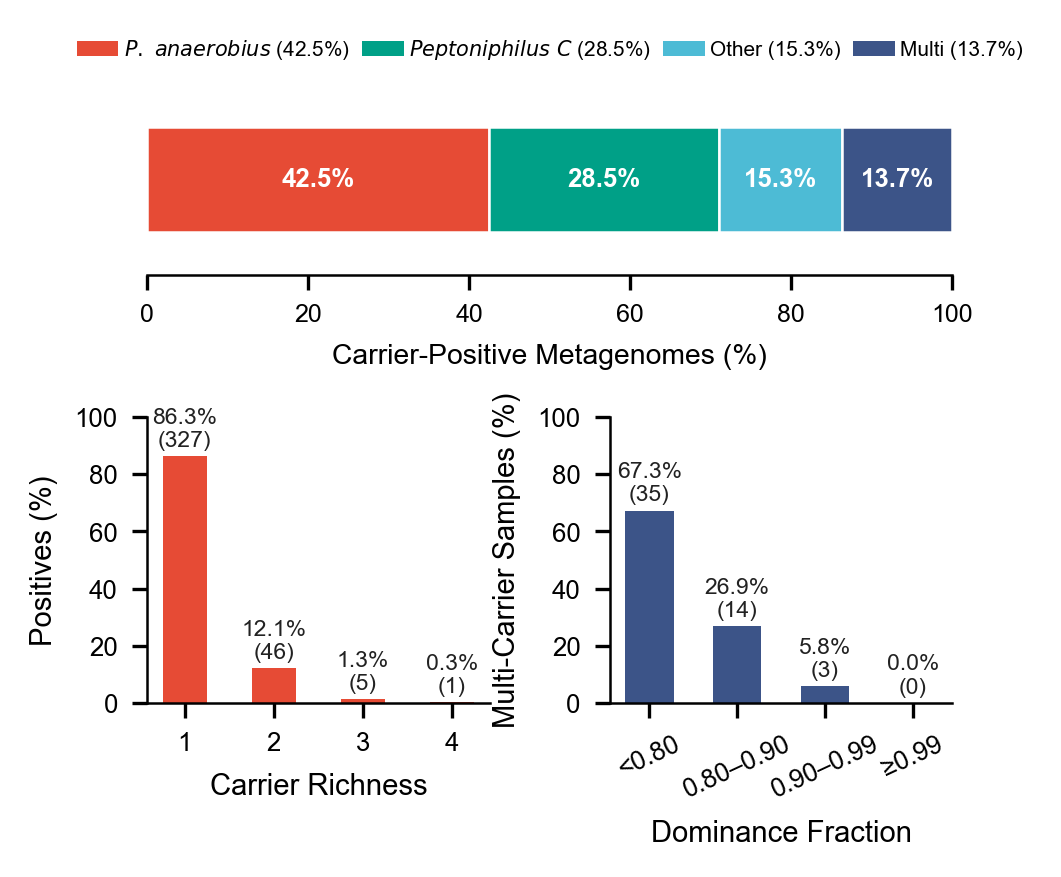

In [5]:
# ==============================================================================
# Panel 2d: Within-sample architecture with multi-carrier dominance
# ==============================================================================
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
    'axes.linewidth': 0.6,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

states_df = pd.read_csv(
    DATA_DIR / 'Figure2d_sample_states.tsv', sep='\t'
)
richness_df = pd.read_csv(
    DATA_DIR / 'Figure2d_richness_distribution.tsv', sep='\t'
)
counts = pd.read_csv(
    DATA_DIR / 'carrier_by_sample_counts.tsv.gz',
    sep='\t',
    index_col=0,
)

# Recompute dominance directly from the 14-carrier count matrix.
presence = counts.gt(0)
sample_richness = presence.sum(axis=0)
total_carrier_reads = counts.sum(axis=0).astype(float)
dominant_carrier_reads = counts.max(axis=0).astype(float)
dominance = dominant_carrier_reads.div(total_carrier_reads.where(total_carrier_reads > 0))

multi_mask = sample_richness.gt(1)
multi_dominance = dominance.loc[multi_mask]
n_multi = int(multi_mask.sum())

expected_multi = int(
    states_df.loc[
        states_df['carrier_state'] == 'Multi-carrier co-colonization',
        'n_samples',
    ].iloc[0]
)
if n_multi != expected_multi:
    raise ValueError(
        f'Multi-carrier sample mismatch: matrix={n_multi}, state table={expected_multi}'
    )
if multi_dominance.isna().any() or ((multi_dominance < 0) | (multi_dominance > 1)).any():
    raise ValueError('Invalid dominance values in multi-carrier samples.')

dominance_labels = ['<0.80', '0.80–0.90', '0.90–0.99', '≥0.99']
dominance_bins = [0.0, 0.8, 0.9, 0.99, 1.0000001]
dominance_group = pd.cut(
    multi_dominance,
    bins=dominance_bins,
    labels=dominance_labels,
    right=False,
    include_lowest=True,
)
dominance_counts = dominance_group.value_counts(sort=False).reindex(
    dominance_labels, fill_value=0
)
dominance_df = pd.DataFrame({
    'dominance_bin': dominance_labels,
    'n_samples': dominance_counts.astype(int).to_numpy(),
})
dominance_df['percent_multicarrier'] = dominance_df['n_samples'] / n_multi * 100.0

if int(dominance_df['n_samples'].sum()) != n_multi:
    raise ValueError('Dominance-bin counts do not sum to the multi-carrier denominator.')

source_path = OUTPUT_DIR / 'source_data' / 'Figure2d_multicarrier_dominance_distribution.tsv'
source_path.parent.mkdir(parents=True, exist_ok=True)
dominance_df.to_csv(source_path, sep='\t', index=False)

STATE_COLORS = {
    'P. anaerobius only': '#E64B35',
    'Peptoniphilus_C only': '#00A087',
    'Other single carrier': '#4DBBD5',
    'Multi-carrier co-colonization': '#3C5488',
}
state_order = [
    'P. anaerobius only',
    'Peptoniphilus_C only',
    'Other single carrier',
    'Multi-carrier co-colonization',
]
pos_states = (
    states_df[states_df['carrier_state'] != 'Carrier-negative']
    .set_index('carrier_state')
    .reindex(state_order)
    .reset_index()
)

fig = plt.figure(figsize=(88 / 25.4, 68 / 25.4), dpi=300)
gs = gridspec.GridSpec(
    2, 2,
    height_ratios=[0.8, 1.2],
    width_ratios=[1.0, 1.0],
    hspace=0.6,
    wspace=0.35,
)
ax_bar = fig.add_subplot(gs[0, :])
ax_rich = fig.add_subplot(gs[1, 0])
ax_dom = fig.add_subplot(gs[1, 1])

# 1. Carrier-positive sample composition
left = 0.0
for _, row in pos_states.iterrows():
    state = row['carrier_state']
    pct = row['percent_positives']
    ax_bar.barh(
        0, pct, left=left, height=0.55,
        color=STATE_COLORS[state], edgecolor='white', linewidth=0.6,
    )
    if pct > 10.0:
        ax_bar.text(
            left + pct / 2, 0, f'{pct:.1f}%',
            ha='center', va='center', fontsize=6.2,
            color='white', fontweight='bold',
        )
    left += pct

ax_bar.set_xlim(0, 100)
ax_bar.set_ylim(-0.5, 0.5)
ax_bar.set_yticks([])
ax_bar.set_xlabel('Carrier-Positive Metagenomes (%)', fontsize=6.8)
ax_bar.tick_params(axis='x', labelsize=6.0)
sns.despine(ax=ax_bar, left=True)

legend_labels = {
    'P. anaerobius only': r'$\mathit{P.\ anaerobius}$',
    'Peptoniphilus_C only': r'$\mathit{Peptoniphilus\ C}$',
    'Other single carrier': 'Other',
    'Multi-carrier co-colonization': 'Multi',
}
legend_handles = [
    Patch(
        facecolor=STATE_COLORS[row.carrier_state],
        label=f"{legend_labels[row.carrier_state]} ({row.percent_positives:.1f}%)",
    )
    for row in pos_states.itertuples()
]
ax_bar.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=4,
    fontsize=5.0,
    frameon=False,
    handletextpad=0.25,
    columnspacing=0.6,
)

# 2. Carrier richness among carrier-positive samples
bars_r = ax_rich.bar(
    richness_df['richness'],
    richness_df['percent_positives'],
    color='#E64B35',
    width=0.5,
    edgecolor='none',
)
ax_rich.set_xlabel('Carrier Richness', fontsize=7.0)
ax_rich.set_ylabel('Positives (%)', fontsize=7.0)
ax_rich.set_xticks(richness_df['richness'])
ax_rich.set_xticklabels(
    [str(r) for r in richness_df['richness']], fontsize=6.5
)
ax_rich.set_ylim(0, 100)
ax_rich.tick_params(axis='both', labelsize=6.2)
sns.despine(ax=ax_rich)

for bar, row in zip(bars_r, richness_df.itertuples()):
    ax_rich.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f'{row.percent_positives:.1f}%\n({int(row.n_samples)})',
        ha='center', va='bottom', fontsize=5.5, color='#222222',
    )

# 3. Dominance restricted to multi-carrier samples
bars_d = ax_dom.bar(
    range(len(dominance_df)),
    dominance_df['percent_multicarrier'],
    color='#3C5488',
    width=0.55,
    edgecolor='none',
)
ax_dom.set_xlabel('Dominance Fraction', fontsize=7.0)
ax_dom.set_ylabel('Multi-Carrier Samples (%)', fontsize=7.0)
ax_dom.set_xticks(range(len(dominance_df)))
ax_dom.set_xticklabels(
    dominance_df['dominance_bin'], fontsize=5.8, rotation=25
)
ax_dom.set_ylim(0, 100)
ax_dom.tick_params(axis='both', labelsize=6.2)
sns.despine(ax=ax_dom)

for bar, row in zip(bars_d, dominance_df.itertuples()):
    ax_dom.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f'{row.percent_multicarrier:.1f}%\n({int(row.n_samples)})',
        ha='center', va='bottom', fontsize=5.5, color='#222222',
    )

out_dir = OUTPUT_DIR
out_dir.mkdir(parents=True, exist_ok=True)
base = out_dir / 'Fig2d_within_sample_architecture_multicarrier_dominance'
for ext, kwargs in [
    ('.svg', {}),
    ('.pdf', {}),
    ('.png', {'dpi': 300}),
    ('.tiff', {'dpi': 600, 'pil_kwargs': {'compression': 'raw'}}),
]:
    fig.savefig(base.with_suffix(ext), bbox_inches='tight', **kwargs)

print(f'Multi-carrier denominator: {n_multi}')
print(dominance_df.to_string(index=False))
print(f'Source data: {source_path.relative_to(REPO_ROOT)}')
print(f'Figure files: {base.relative_to(REPO_ROOT)}.[svg|pdf|png|tiff]')
plt.show()
